# FASTR Gradient Artifact Removal Demo

Demostracion del primer preprocesado para EEG-fMRI: filtro pasa-banda (0.1-70 Hz) y eliminacion del artefacto de gradiente mediante FASTR. El archivo `.set` se carga con MNE, que localiza automaticamente el `.fdt` asociado.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import mne
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from functions.fastr_ga import FASTRConfig, bandpass_filter, fastr_remove_gradient_artifact

In [11]:
DEFAULT_EEG_ROOT = PROJECT_ROOT / 'data/raw/Dataset1/Simultaneous_EEG_fMRI/BIDS_dataset_EEG'
SUBJECT = 'sub-001'
TASK = 'fmrirestingec'

# Debe ser el periodo de repeticion del artefacto. Usa el periodo por corte
# si se dispone de triggers de slice; como alternativa se usa el TR (2 s).
ARTIFACT_PERIOD_S = 2.0
LOW_HZ, HIGH_HZ = 0.1, 70.0
TEMPLATE_WINDOW = 21
PCA_COMPONENTS = 4

# Activa esta opcion para detectar T0/Tf por la morfologia periodica del GA
# y aplicar FASTR solo durante la adquisicion fMRI. Requiere TR y N_SLICES.
USE_FMRI_BOUNDS = True
TR_SECONDS = 2.0
N_SLICES = 35  # Sustituir por el numero real de slices al activar la deteccion
CALIBRATION_SECONDS = 5.0
CHANNEL_INDEX = 0
START_S = 60
DISPLAY_SECONDS = 10

In [14]:
eeg_path = DEFAULT_EEG_ROOT / SUBJECT / 'eeg' / f'{SUBJECT}_task-{TASK}_eeg.set'
if not eeg_path.is_file():
    raise FileNotFoundError(f'EEGLAB header not found: {eeg_path}')

raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose='ERROR')
eeg_data = raw.get_data()
fs = float(raw.info['sfreq'])
print(f'Input: {eeg_path.name}')
print(f'Shape: {eeg_data.shape}; fs: {fs} Hz; channels: {len(raw.ch_names)}')
print(f'Example channel: {CHANNEL_INDEX} ({raw.ch_names[CHANNEL_INDEX]})')

Input: sub-001_task-fmrirestingec_eeg.set
Shape: (33, 639320); fs: 1000.0 Hz; channels: 33
Example channel: 0 (E1)


## Senal antes de FASTR

La traza incluye el EEG crudo registrado dentro del escaner.

In [4]:
mne.viz.set_browser_backend('qt')
raw.plot(
    n_channels=20,
    duration=10,
    show_scrollbars=True,
    block=True,
)

Using qt as 2D backend.
Channels marked as bad:
none


In [15]:
filtered = bandpass_filter(eeg_data, fs, low_hz=LOW_HZ, high_hz=HIGH_HZ)
fastr_result = fastr_remove_gradient_artifact(
    filtered,
    fs,
    FASTRConfig(
        artifact_period_s=ARTIFACT_PERIOD_S,
        template_window=TEMPLATE_WINDOW,
        pca_components=PCA_COMPONENTS,
        use_fmri_bounds=USE_FMRI_BOUNDS,
        tr_sec=TR_SECONDS,
        n_slices=N_SLICES,
        calibration_seconds=CALIBRATION_SECONDS,
    ),
    detection_signal=eeg_data,
    channel_names=raw.ch_names,
)
cleaned = fastr_result['cleaned_signal']
print(f"Estimated offset: {fastr_result['offset']} samples")
print(f"Artifact period: {fastr_result['period_samples']} samples")
if USE_FMRI_BOUNDS:
    print(f"Detected T_GA: {fastr_result['fmri_start_sample']} samples ({fastr_result['fmri_start_sec']:.3f} s)")
    print(f"Detected T_GA_end: {fastr_result['fmri_end_sample']} samples ({fastr_result['fmri_end_sec']:.3f} s)")
    print(f"Stable T_BOLD: {fastr_result['t_bold_sample']} samples ({fastr_result['t_bold_sec']:.3f} s)")

Estimated offset: 532 samples
Artifact period: 2000 samples
Detected T_GA: 10750 samples (10.750 s)
Detected T_GA_end: 639281 samples (639.281 s)
Stable T_BOLD: 40977 samples (40.977 s)


## Visualizacion despues de FASTR

Crea un objeto `Raw` de MNE con los datos procesados para navegar por los canales igual que en el demo de AAS.

In [16]:
raw_clean = raw.copy()
raw_clean._data = cleaned.copy()
raw_clean.plot(
    n_channels=20,
    duration=10,
    show_scrollbars=True,
    block=True,
)

Channels marked as bad:
none


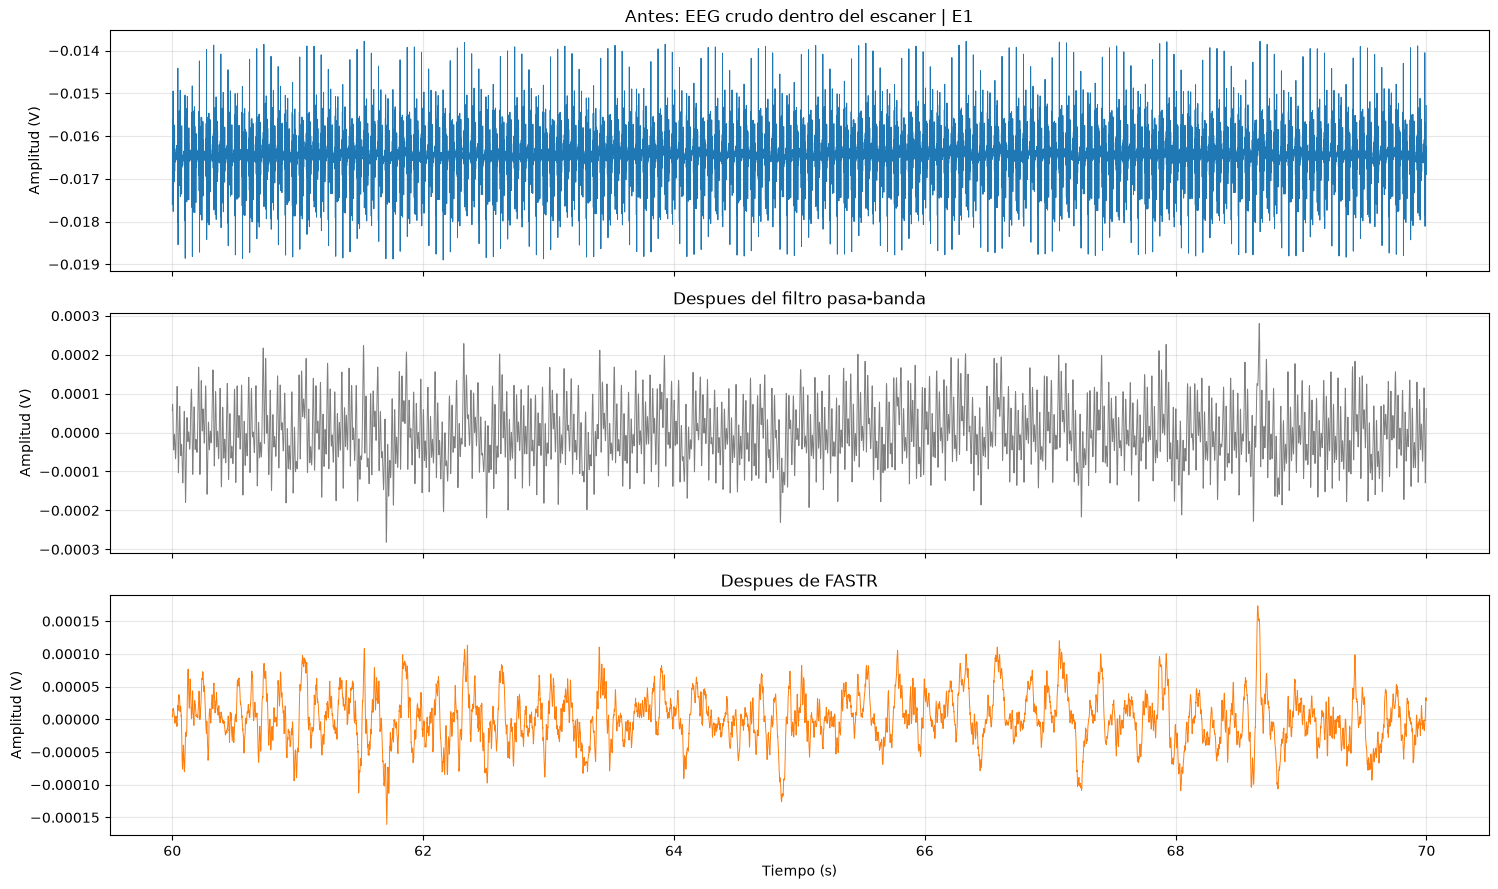

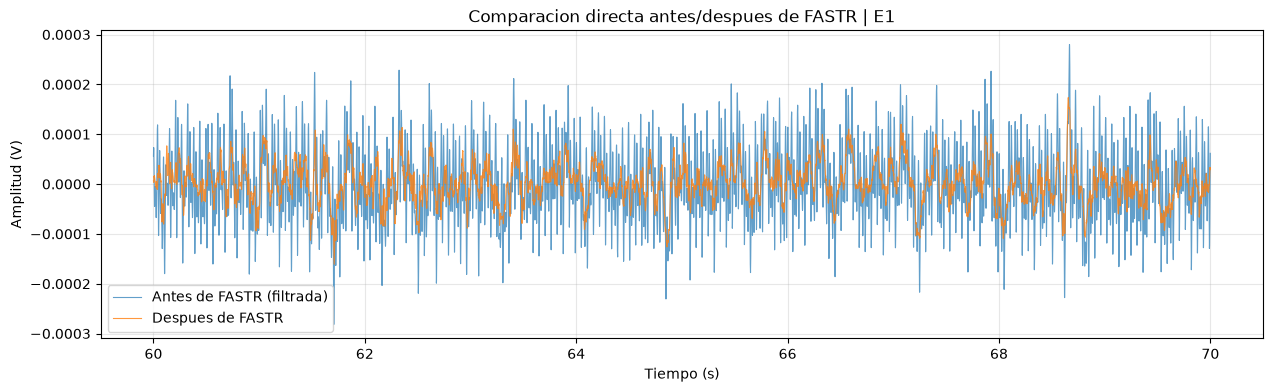

In [17]:
start = int(round(START_S * fs))
stop = min(start + int(round(DISPLAY_SECONDS * fs)), eeg_data.shape[1])
time = np.arange(start, stop) / fs
channel_name = raw.ch_names[CHANNEL_INDEX]

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
axes[0].plot(time, eeg_data[CHANNEL_INDEX, start:stop], lw=0.7, color='tab:blue')
axes[0].set_title(f'Antes: EEG crudo dentro del escaner | {channel_name}')
axes[1].plot(time, filtered[CHANNEL_INDEX, start:stop], lw=0.7, color='tab:gray')
axes[1].set_title('Despues del filtro pasa-banda')
axes[2].plot(time, cleaned[CHANNEL_INDEX, start:stop], lw=0.7, color='tab:orange')
axes[2].set_title('Despues de FASTR')
for axis in axes:
    axis.set_ylabel('Amplitud (V)')
    axis.grid(alpha=0.3)
axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(time, filtered[CHANNEL_INDEX, start:stop], label='Antes de FASTR (filtrada)', alpha=0.7, lw=0.8)
plt.plot(time, cleaned[CHANNEL_INDEX, start:stop], label='Despues de FASTR', alpha=0.8, lw=0.8)
plt.title(f'Comparacion directa antes/despues de FASTR | {channel_name}')
plt.xlabel('Tiempo (s)'); plt.ylabel('Amplitud (V)'); plt.grid(alpha=0.3); plt.legend(); plt.show()

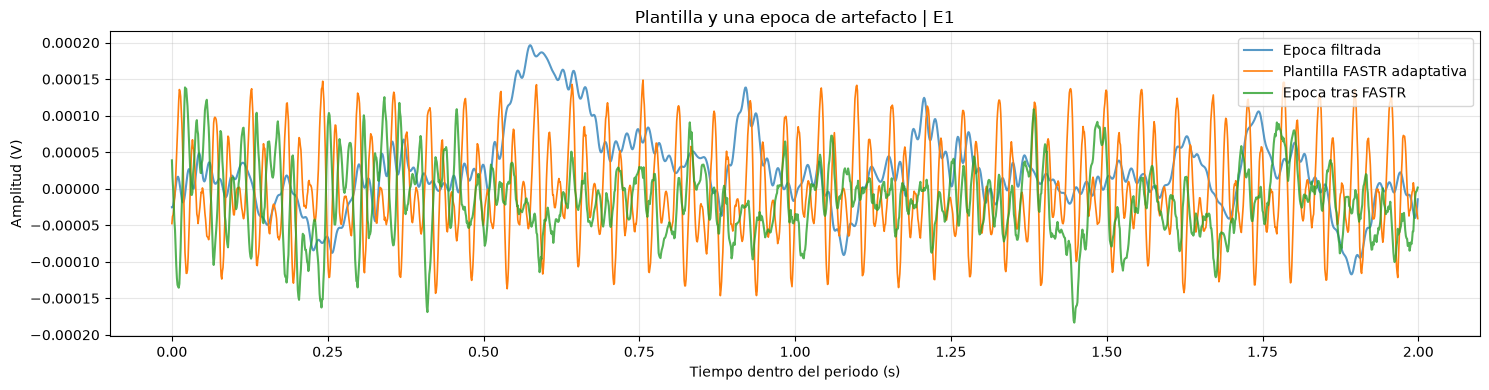

In [18]:
period = int(fastr_result['period_samples'])
template = fastr_result['templates'][CHANNEL_INDEX, 0]
before_epoch = filtered[CHANNEL_INDEX, int(fastr_result['offset']):int(fastr_result['offset']) + period]
after_epoch = fastr_result['cleaned_epochs'][CHANNEL_INDEX, 0]
epoch_time = np.arange(period) / fs
plt.figure(figsize=(15, 4))
plt.plot(epoch_time, before_epoch, label='Epoca filtrada', alpha=0.75)
plt.plot(epoch_time, template, label='Plantilla FASTR adaptativa', lw=1.2)
plt.plot(epoch_time, after_epoch, label='Epoca tras FASTR', alpha=0.8)
plt.title(f'Plantilla y una epoca de artefacto | {channel_name}')
plt.xlabel('Tiempo dentro del periodo (s)'); plt.ylabel('Amplitud (V)')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()